In [1]:
!pip install pyspark -q

In [2]:
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd

In [3]:
import os

for dirname, dirs, files in os.walk('/kaggle/input/datasets'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(dirname, file))

/kaggle/input/datasets/hadaaaa/movielens-latest/movies.csv
/kaggle/input/datasets/hadaaaa/movielens-latest/ratings.csv
/kaggle/input/datasets/hadaaaa/movielens-latest/genome-tags.csv
/kaggle/input/datasets/hadaaaa/movielens-latest/genome-scores.csv
/kaggle/input/datasets/hadaaaa/movielens-latest/tags.csv
/kaggle/input/datasets/hadaaaa/movielens-latest/links.csv


In [4]:
spark = SparkSession.builder \
    .appName("MovieLens33M") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/16 14:47:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [5]:
ratings = spark.read.csv(
    "/kaggle/input/datasets/hadaaaa/movielens-latest/ratings.csv",
    header=True,
    inferSchema=True
)

movies = spark.read.csv(
    "/kaggle/input/datasets/hadaaaa/movielens-latest/movies.csv",
    header=True,
    inferSchema=True
)

# 1. Data Quality Checking & Data Understanding 

In [6]:
# %% [markdown]
# # 1. Data Quality Checking & Data Understanding

# %%
# Pengecekan Schema Data
print("=== Schema Tabel Ratings ===")
ratings.printSchema()

print("\n=== Schema Tabel Movies ===")
movies.printSchema()

# %%
# Menghitung Jumlah Data dan Duplikasi/Unik
print(f"Total baris ratings: {ratings.count():,}")
print(f"Total baris movies : {movies.count():,}")

from pyspark.sql.functions import countDistinct
ratings.select(
    countDistinct("userId").alias("Total Unique Users"),
    countDistinct("movieId").alias("Total Unique Movies")
).show()

# %%
# Pengecekan Missing Values (Data Quality Check)
from pyspark.sql.functions import col, sum as _sum

print("Pengecekan Null Values pada Tabel Ratings:")
ratings.select([_sum(col(c).isNull().cast("int")).alias(c) for c in ratings.columns]).show()

print("Pengecekan Null Values pada Tabel Movies:")
movies.select([_sum(col(c).isNull().cast("int")).alias(c) for c in movies.columns]).show()

# %%
# Menampilkan Sampel Data Awal
print("5 Data Pertama Ratings:")
ratings.show(5)

=== Schema Tabel Ratings ===
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)


=== Schema Tabel Movies ===
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)



Total baris ratings: 33,832,162
Total baris movies : 86,537


+------------------+-------------------+
|Total Unique Users|Total Unique Movies|
+------------------+-------------------+
|            330975|              83239|
+------------------+-------------------+

Pengecekan Null Values pada Tabel Ratings:


+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+

Pengecekan Null Values pada Tabel Movies:
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+

5 Data Pertama Ratings:
+------+-------+------+----------+
|userId|movieId|rating| timestamp|
+------+-------+------+----------+
|     1|      1|   4.0|1225734739|
|     1|    110|   4.0|1225865086|
|     1|    158|   4.0|1225733503|
|     1|    260|   4.5|1225735204|
|     1|    356|   5.0|1225735119|
+------+-------+------+----------+
only showing top 5 rows


# 2. Exploratory Data Analysis

Mengambil data agregasi dari Spark...


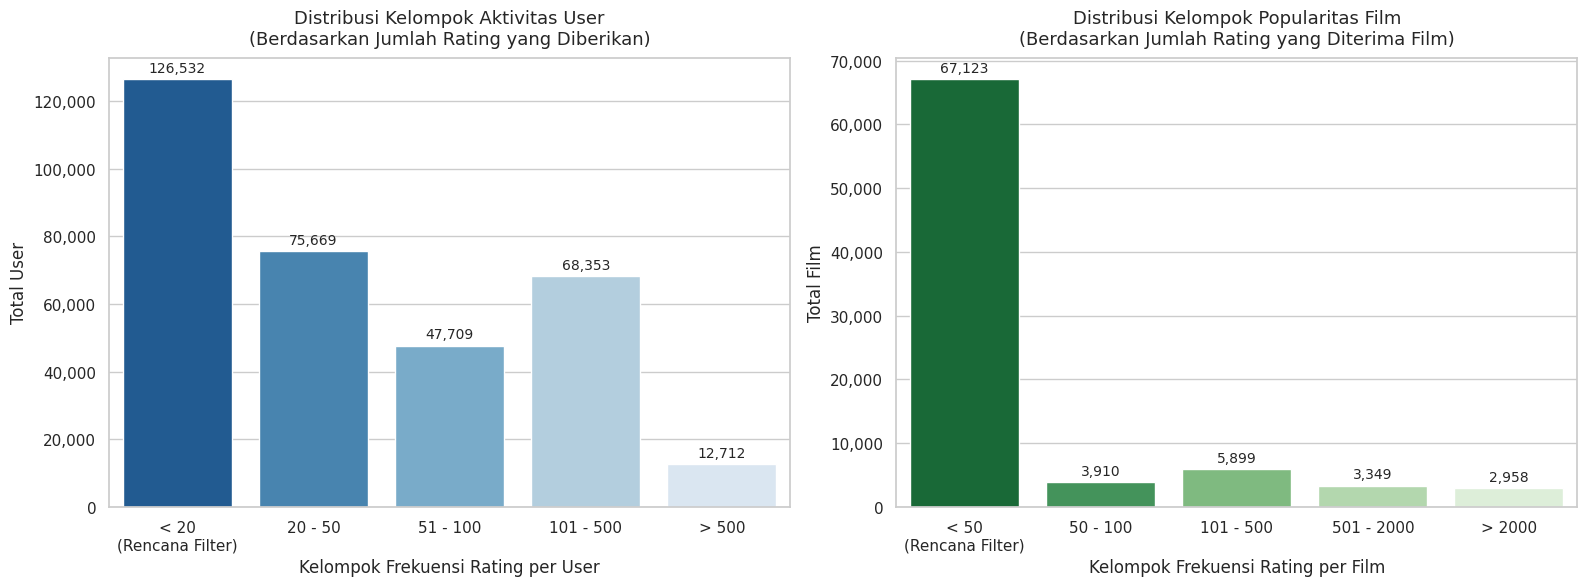


 TABEL DISTRIBUSI KELOMPOK (UNTUK NARRATIVE JURNAL)

[Tabel Kategori User]
       Kelompok_Rating Jumlah_User
< 20\n(Rencana Filter)     126,532
               20 - 50      75,669
              51 - 100      47,709
             101 - 500      68,353
                 > 500      12,712

[Tabel Kategori Film]
  Kelompok_Popularitas Jumlah_Film
< 50\n(Rencana Filter)      67,123
              50 - 100       3,910
             101 - 500       5,899
            501 - 2000       3,349
                > 2000       2,958


In [7]:
# %% [markdown]
# # 2. Exploratory Data Analysis (EDA) & Visualisasi (Grouped Interval) - Fixed Palette

# %%
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Atur gaya visualisasi jurnal ilmiah
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13})

# ==================================================
# 1. AGREGASI DATA DARI SPARK
# ==================================================
print("Mengambil data agregasi dari Spark...")
user_activity_pd = ratings.groupBy("userId").count().toPandas()
movie_popularity_pd = ratings.groupBy("movieId").count().toPandas()

# ==================================================
# 2. PENGELOMPOKAN (BINNING) AKTIVITAS USER
# ==================================================
bins_user = [0, 19, 50, 100, 500, float('inf')]
labels_user = ['< 20\n(Rencana Filter)', '20 - 50', '51 - 100', '101 - 500', '> 500']
user_activity_pd['Kelompok_Rating'] = pd.cut(user_activity_pd['count'], bins=bins_user, labels=labels_user)

user_grouped = user_activity_pd['Kelompok_Rating'].value_counts().sort_index().reset_index()
user_grouped.columns = ['Kelompok_Rating', 'Jumlah_User']

# ==================================================
# 3. PENGELOMPOKAN (BINNING) POPULARITAS FILM
# ==================================================
bins_movie = [0, 49, 100, 500, 2000, float('inf')]
labels_movie = ['< 50\n(Rencana Filter)', '50 - 100', '101 - 500', '501 - 2000', '> 2000']
movie_popularity_pd['Kelompok_Popularitas'] = pd.cut(movie_popularity_pd['count'], bins=bins_movie, labels=labels_movie)

movie_grouped = movie_popularity_pd['Kelompok_Popularitas'].value_counts().sort_index().reset_index()
movie_grouped.columns = ['Kelompok_Popularitas', 'Jumlah_Film']


# ==================================================
# 4. VISUALISASI GRAFIK BERPASANGAN (SIDE-BY-SIDE)
# ==================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Kiri: Kelompok Aktivitas User
sns.barplot(
    x="Kelompok_Rating", y="Jumlah_User", data=user_grouped, 
    palette="Blues_r", hue="Kelompok_Rating", legend=False, ax=ax1
)
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax1.set_title("Distribusi Kelompok Aktivitas User\n(Berdasarkan Jumlah Rating yang Diberikan)", pad=10)
ax1.set_xlabel("Kelompok Frekuensi Rating per User")
ax1.set_ylabel("Total User")

# Tambahkan label angka di atas bar plot kiri
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10)

# Plot Kanan: Kelompok Popularitas Film (MENGGUNAKAN GREENS_R YANG AMAN)
sns.barplot(
    x="Kelompok_Popularitas", y="Jumlah_Film", data=movie_grouped, 
    palette="Greens_r", hue="Kelompok_Popularitas", legend=False, ax=ax2
)
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax2.set_title("Distribusi Kelompok Popularitas Film\n(Berdasarkan Jumlah Rating yang Diterima Film)", pad=10)
ax2.set_xlabel("Kelompok Frekuensi Rating per Film")
ax2.set_ylabel("Total Film")

# Tambahkan label angka di atas bar plot kanan
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

# ==================================================
# 5. TAMPILKAN TABEL DISTRIBUSI UNTUK DATA JURNAL
# ==================================================
print("\n" + "="*40)
print(" TABEL DISTRIBUSI KELOMPOK (UNTUK NARRATIVE JURNAL)")
print("="*40)
print("\n[Tabel Kategori User]")
print(user_grouped.to_string(index=False, formatters={'Jumlah_User': '{:,}'.format}))
print("\n[Tabel Kategori Film]")
print(movie_grouped.to_string(index=False, formatters={'Jumlah_Film': '{:,}'.format}))

# 3. Data Pre-processing

In [8]:
# %% [markdown]
# # 3. Data Preprocessing

# %%
from pyspark.sql.functions import count, rand, col, ceil, row_number
from pyspark.sql.window import Window

# ==================================================
# A. FILTER USER AKTIF & FILM POPULER
# ==================================================
active_users = (
    ratings.groupBy("userId")
    .agg(count("*").alias("num_ratings"))
    .filter("num_ratings >= 20")
)

popular_movies = (
    ratings.groupBy("movieId")
    .agg(count("*").alias("num_ratings"))
    .filter("num_ratings >= 50")
)

ratings_filtered = (
    ratings.join(active_users, "userId")
           .join(popular_movies, "movieId")
           .select("userId", "movieId", "rating")
)

# ==================================================
# B. SELEKSI RATING POSITIF & ELIGIBILITY USERS
# ==================================================
positive_ratings_all = ratings_filtered.filter("rating >= 4")

eligible_users_all = (
    positive_ratings_all
    .groupBy("userId")
    .agg(count("*").alias("num_positive"))
    .filter("num_positive >= 15")
)

# ==================================================
# C. SAMPLING 10.000 USERS & LOCK MEMORY (CACHE)
# ==================================================
sampled_eligible_users = (
    eligible_users_all
    .select("userId")
    .distinct()
    .orderBy(rand(seed=42))
    .limit(10000)
    .cache()
)

# Trigger Action agar ter-cache sempurna
sampled_eligible_users.count()

ratings_sample = ratings_filtered.join(sampled_eligible_users, "userId")
positive_ratings = positive_ratings_all.join(sampled_eligible_users, "userId")

# ==================================================
# D. STRATIFIED HOLD-OUT SPLITTING (20% PER USER)
# ==================================================
window = Window.partitionBy("userId").orderBy(rand(seed=42))

positive_ranked = positive_ratings.withColumn("rn", row_number().over(window))

user_counts = positive_ratings.groupBy("userId").agg(count("*").alias("num_positive"))
user_counts = user_counts.withColumn("test_size", ceil(col("num_positive") * 0.2))

positive_ranked = positive_ranked.join(user_counts.select("userId", "test_size"), "userId")

# Dataset Test (20% item positif)
test = positive_ranked.filter(col("rn") <= col("test_size")).select("userId", "movieId", "rating")

# Dataset Train (Sisa data keseluruhan minus item test)
train = ratings_sample.join(test.select("userId", "movieId"), ["userId", "movieId"], "left_anti")

print(f"Jumlah Rating Data Train : {train.count():,}")
print(f"Jumlah Rating Data Test  : {test.count():,}")

Jumlah Rating Data Train : 1,612,868


Jumlah Rating Data Test  : 183,155


In [9]:
# %% [markdown]
# # 2.1 Analisis Kerapatan Data (Sparsity Analysis)

# %%
# 1. Menghitung Sparsity Dataset Awal (Raw Data)
total_ratings_raw = ratings.count()
unique_users_raw = ratings.select("userId").distinct().count()
unique_movies_raw = ratings.select("movieId").distinct().count()

total_possible_cells_raw = unique_users_raw * unique_movies_raw
sparsity_raw = (1.0 - (total_ratings_raw / total_possible_cells_raw)) * 100
density_raw = 100.0 - sparsity_raw

# 2. Menghitung Sparsity Dataset Setelah Preprocessing & Sampling (Train Set)
# Catatan: Jalankan ini setelah variabel 'train' terbentuk di langkah Preprocessing
total_ratings_train = train.count()
unique_users_train = train.select("userId").distinct().count()
unique_movies_train = train.select("movieId").distinct().count()

total_possible_cells_train = unique_users_train * unique_movies_train
sparsity_train = (1.0 - (total_ratings_train / total_possible_cells_train)) * 100
density_train = 100.0 - sparsity_train

# ==================================================
# CETAK HASIL ANALISIS SPARSITY
# ==================================================
print("=" * 60)
print("               ANALISIS SPARSITY DATASET")
print("=" * 60)
print("DATASET AWAL (RAW DATA):")
print(f"  • Total Matriks Maksimal : {total_possible_cells_raw:,} sel")
print(f"  • Total Rating Eksis     : {total_ratings_raw:,} rating")
print(f"  • Kerapatan Data (Density): {density_raw:.4f}%")
print(f"  • Tingkat Kekosongan (Sparsity): {sparsity_raw:.4f}%")
print("-" * 60)
print("DATASET TRAINING (AFTER FILTER & SAMPLING):")
print(f"  • Total Matriks Maksimal : {total_possible_cells_train:,} sel")
print(f"  • Total Rating Eksis     : {total_ratings_train:,} rating")
print(f"  • Kerapatan Data (Density): {density_train:.4f}%")
print(f"  • Tingkat Kekosongan (Sparsity): {sparsity_train:.4f}%")
print("=" * 60)

               ANALISIS SPARSITY DATASET
DATASET AWAL (RAW DATA):
  • Total Matriks Maksimal : 27,550,028,025 sel
  • Total Rating Eksis     : 33,832,162 rating
  • Kerapatan Data (Density): 0.1228%
  • Tingkat Kekosongan (Sparsity): 99.8772%
------------------------------------------------------------
DATASET TRAINING (AFTER FILTER & SAMPLING):
  • Total Matriks Maksimal : 160,560,000 sel
  • Total Rating Eksis     : 1,612,868 rating
  • Kerapatan Data (Density): 1.0045%
  • Tingkat Kekosongan (Sparsity): 98.9955%


# 4. Model Building

In [10]:
# %% [markdown]
# # 4. Pembangunan Model Recommendation System (ALS)

# %%
from pyspark.ml.recommendation import ALS

# Inisialisasi Model ALS
als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    rank=50,
    maxIter=10,
    regParam=0.05,
    coldStartStrategy="drop",
    nonnegative=True,
    seed=42
)

# Pelatihan Model
print("Memulai proses training model ALS...")
model = als.fit(train)
print("Model ALS berhasil dibangun.")

Memulai proses training model ALS...


Model ALS berhasil dibangun.


# 5. Evaluasi Model

In [11]:
# %% [markdown]
# # 5. Evaluasi Model

# %%
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import collect_set, expr, size, array_intersect, when, avg

# ==================================================
# A. EVALUASI ERROR (RMSE)
# ==================================================
predictions = model.transform(test)

rmse = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
).evaluate(predictions)

# ==================================================
# B. PREPARASI DATA AKTUAL VS REKOMENDASI (TOP-20)
# ==================================================
actual = test.groupBy("userId").agg(collect_set("movieId").alias("actual_movies"))

# Generate Top 20 rekomendasi film untuk setiap user
user_recs = model.recommendForAllUsers(20)

predicted = user_recs.withColumn(
    "predicted_movies",
    expr("transform(recommendations, x -> x.movieId)")
).select("userId", "predicted_movies")

# Gabungkan data aktual dan prediksi
evaluation_df = actual.join(predicted, on="userId", how="inner")

# ==================================================
# C. PERHITUNGAN HIT, PRECISION, DAN RECALL
# ==================================================
evaluation_df = evaluation_df.withColumn(
    "hits",
    size(array_intersect("actual_movies", "predicted_movies"))
)

precision_df = evaluation_df.withColumn("precision", col("hits") / 20.0)
recall_df = precision_df.withColumn("recall", col("hits") / size("actual_movies"))
result_df = recall_df.withColumn("hit", when(col("hits") > 0, 1.0).otherwise(0.0))

# Mengambil nilai rata-rata metrik
hit_rate = result_df.agg(avg("hit")).collect()[0][0]
precision = result_df.agg(avg("precision")).collect()[0][0]
recall = result_df.agg(avg("recall")).collect()[0][0]

# ==================================================
# D. RINGKASAN EKSEKUTIF UNTUK JURNAL
# ==================================================
total_users_modeled = train.select("userId").distinct().count()
total_movies_modeled = train.select("movieId").distinct().count()

print("=" * 60)
print("         RANGKUMAN METRIC & DIMENSI MODELING ALS")
print("=" * 60)
print(f"SAMPEL DATASET:")
print(f"  • Total Users Terlibat     : {total_users_modeled:,}")
print(f"  • Total Movies Terlibat    : {total_movies_modeled:,}")
print(f"  • Jumlah Rating (Train)    : {train.count():,}")
print(f"  • Jumlah Rating (Test)     : {test.count():,}")
print("-" * 60)
print(f"METRIK EVALUASI:")
print(f"  • RMSE                     : {rmse:.4f}")
print(f"  • HitRate@20               : {hit_rate:.4f} ({hit_rate*100:.2f}%)")
print(f"  • Precision@20             : {precision:.4f} ({precision*100:.2f}%)")
print(f"  • Recall@20                : {recall:.4f} ({recall*100:.2f}%)")
print("=" * 60)

         RANGKUMAN METRIC & DIMENSI MODELING ALS
SAMPEL DATASET:
  • Total Users Terlibat     : 10,000
  • Total Movies Terlibat    : 16,056


  • Jumlah Rating (Train)    : 1,612,868


  • Jumlah Rating (Test)     : 183,155
------------------------------------------------------------
METRIK EVALUASI:
  • RMSE                     : 0.6785
  • HitRate@20               : 0.1937 (19.37%)
  • Precision@20             : 0.0127 (1.27%)
  • Recall@20                : 0.0232 (2.32%)
